<a href="https://colab.research.google.com/github/hasinduW/SE4050-waste-classification-4models/blob/Updated-ResNet50/DL_Waste_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     GlobalAveragePooling2D, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2, ResNet50 # Import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

tf.__version__

'2.19.0'

In [ ]:
# STEP 1 — Paths & Config
DATA_DIR = '/content/drive/MyDrive/Waste Images'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.20
EPOCHS     = 8          # keep 5–10 for fast runs
LR         = 1e-4
SEED       = 42
tf.keras.utils.set_random_seed(SEED)

assert os.path.isdir(DATA_DIR), f"Folder not found: {DATA_DIR}"


In [ ]:
# STEP 2 — Data Generators (Preprocess & Aug)
# a) Plain preprocessing (for Baseline)
base_gen = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT)

train_base = base_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, subset='training', seed=SEED)

val_base = base_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, subset='validation', seed=SEED)

# b) With augmentation (for Aug CNN & MobileNetV2)
aug_gen = ImageDataGenerator(
    rescale=1./255, validation_split=VAL_SPLIT,
    rotation_range=25, width_shift_range=0.2, height_shift_range=0.2,
    zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
)

train_aug = aug_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, subset='training', seed=SEED)

val_aug = aug_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, subset='validation', seed=SEED)

class_names = list(train_base.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)


Found 6593 images belonging to 9 classes.
Found 1642 images belonging to 9 classes.
Found 6593 images belonging to 9 classes.
Found 1642 images belonging to 9 classes.
Classes: ['Aluminium', 'Carton', 'E-waste', 'Glass', 'Organic_Waste', 'Paper_and_Cardboard', 'Plastics', 'Textiles', 'Wood']


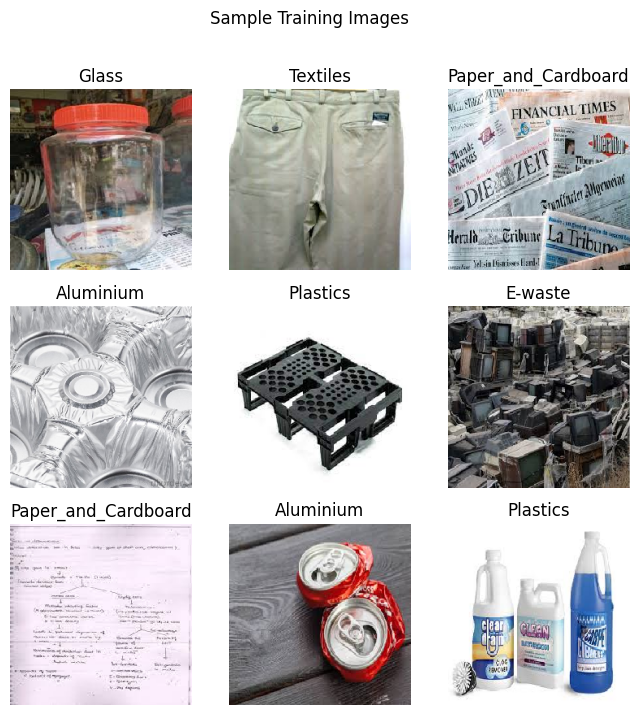

In [ ]:

# STEP 3 — Peek some training data
x_batch, y_batch = next(train_base)
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(class_names[np.argmax(y_batch[i])])
    plt.axis('off')
plt.suptitle("Sample Training Images")
plt.show()


In [ ]:
# Utilities — plotting & evaluation helpers
def plot_history(history, title=""):
    plt.figure(figsize=(12,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc'); plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.show()

def eval_and_report(model, val_gen, title=""):
    # Evaluate
    loss, acc = model.evaluate(val_gen, verbose=0)
    print(f"{title} — Val Accuracy: {acc*100:.2f}% | Val Loss: {loss:.4f}")
    # Predict
    preds = model.predict(val_gen, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = val_gen.classes
    # Confusion matrix
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(7,6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    plt.title(f'Confusion Matrix — {title}')
    plt.show()
    # Classif report
    print(classification_report(true_labels, pred_labels, target_names=class_names))

In [ ]:
# STEP 4 — Callbacks (ES, LR scheduler, CKPT)

ckpt_dir = '/content/drive/MyDrive/Waste_Images/checkpoints'
os.makedirs(ckpt_dir, exist_ok=True)

def common_callbacks(tag):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(os.path.join(ckpt_dir, f'best_{tag}.keras'),
                        monitor='val_loss', save_best_only=True, verbose=1)
    ]


In [ ]:
# MODEL 3 — FIXED ResNet50 (Optimized Transfer Learning)

aug_gen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # 🆕 Correct preprocessing for ResNet50
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_resnet = aug_gen_resnet.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, subset='training', seed=SEED)

val_resnet = aug_gen_resnet.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, subset='validation', seed=SEED)

Found 6593 images belonging to 9 classes.
Found 1642 images belonging to 9 classes.


In [ ]:
# 🆕 Load Pre-Trained ResNet50 Model
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE,3))
for layer in base_resnet.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True
    else:
        layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 🆕 Add custom classification head ( Build the Model )
resnet_model = Sequential([
    base_resnet,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

🔹 Stage 1: training new dense layers...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.4337 - loss: 1.6315 
Epoch 1: val_loss improved from inf to 0.72064, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_resnet50_stage1.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 4880s 23s/step - accuracy: 0.4345 - loss: 1.6294 - val_accuracy: 0.7400 - val_loss: 0.7206 - learning_rate: 1.0000e-04
Epoch 2/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.7761 - loss: 0.6634 
Epoch 2: val_loss improved from 0.72064 to 0.57878, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_resnet50_stage1.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 4733s 23s/step - accuracy: 0.7762 - loss: 0.6632 - val_accuracy: 0.8015 - val_loss: 0.5788 - learning_rate: 1.0000e-04
Epoch 3/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.8092 - loss: 0.5419 
Epoch 3: val_loss improved from 0.57878 to 0.52748, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_resnet50_stage1.keras
207/207 ━━━━━━━━━━━━━

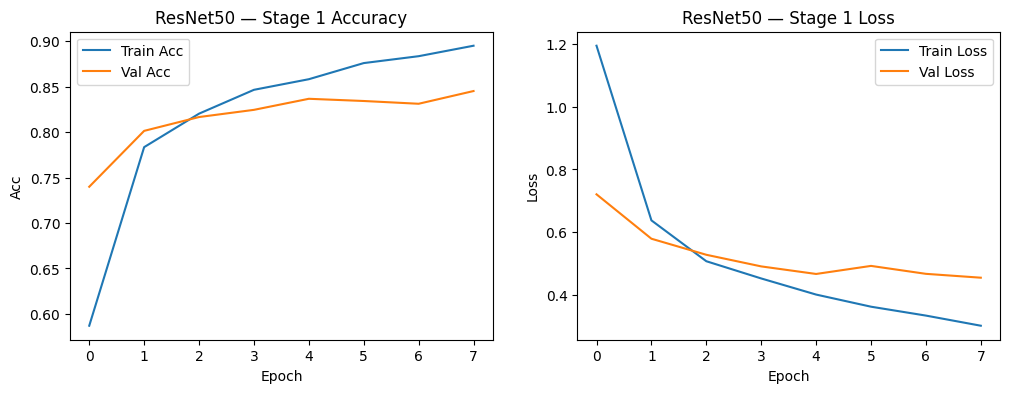

ResNet50 — Stage 1 — Val Accuracy: 83.80% | Val Loss: 0.4499


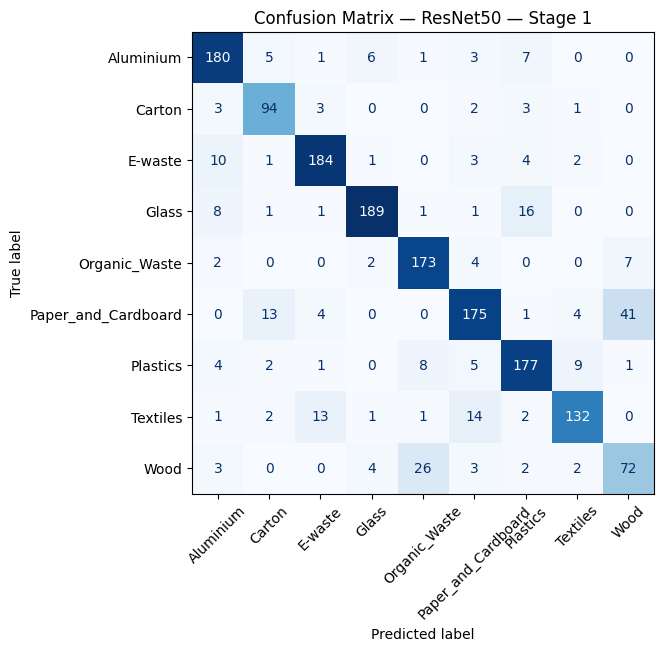

                     precision    recall  f1-score   support

          Aluminium       0.85      0.89      0.87       203
             Carton       0.80      0.89      0.84       106
            E-waste       0.89      0.90      0.89       205
              Glass       0.93      0.87      0.90       217
      Organic_Waste       0.82      0.92      0.87       188
Paper_and_Cardboard       0.83      0.74      0.78       238
           Plastics       0.83      0.86      0.84       207
           Textiles       0.88      0.80      0.84       166
               Wood       0.60      0.64      0.62       112

           accuracy                           0.84      1642
          macro avg       0.83      0.83      0.83      1642
       weighted avg       0.84      0.84      0.84      1642



In [ ]:
# 🆕 Stage 1 — train only new top layers
resnet_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
print("🔹 Stage 1: training new dense layers...")
hist_resnet_s1 = resnet_model.fit(
    train_resnet, validation_data=val_resnet,
    epochs=8, callbacks=common_callbacks('resnet50_stage1'), verbose=1
)
plot_history(hist_resnet_s1, "ResNet50 — Stage 1")
eval_and_report(resnet_model, val_resnet, "ResNet50 — Stage 1")

In [ ]:
resnet_model.load_weights('/content/drive/MyDrive/Waste_Images/checkpoints/best_resnet50_stage1.keras')
print("Loaded Stage 1 weights successfully!")

Loaded Stage 1 weights successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 294 variables whereas the saved optimizer has 222 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



 Stage 2: fine-tuning last 60 layers...
Epoch 1/12
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.9030 - loss: 0.2731 
Epoch 1: val_loss improved from inf to 0.41474, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_resnet50_stage2.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 3683s 18s/step - accuracy: 0.9031 - loss: 0.2731 - val_accuracy: 0.8557 - val_loss: 0.4147 - learning_rate: 1.0000e-05
Epoch 2/12
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.9196 - loss: 0.2381 
Epoch 2: val_loss did not improve from 0.41474
207/207 ━━━━━━━━━━━━━━━━━━━━ 3649s 18s/step - accuracy: 0.9196 - loss: 0.2380 - val_accuracy: 0.8557 - val_loss: 0.4298 - learning_rate: 1.0000e-05
Epoch 3/12
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9325 - loss: 0.1962 
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_loss did not improve from 0.41474
207/207 ━━━━━━━━━━━━━━━━━━━━ 3216s 16s/step - accuracy: 0.9325 - loss: 0.1962 - val_accuracy

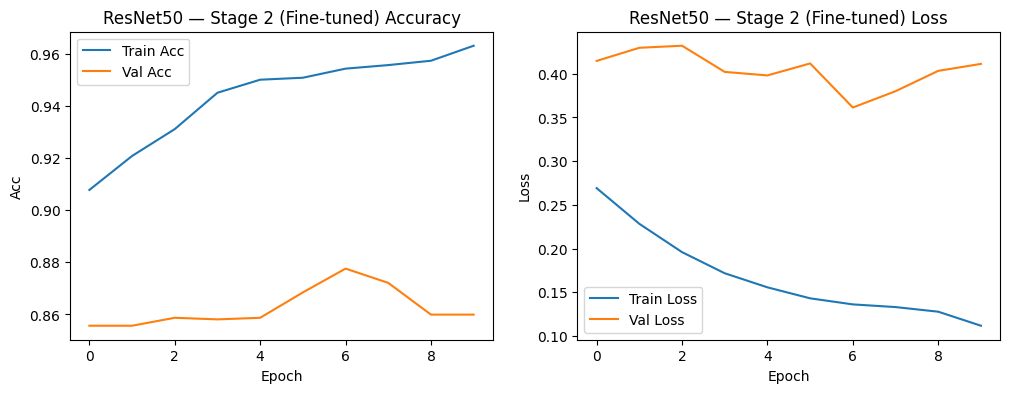

ResNet50 — Stage 2 (Fine-tuned) — Val Accuracy: 87.39% | Val Loss: 0.3598


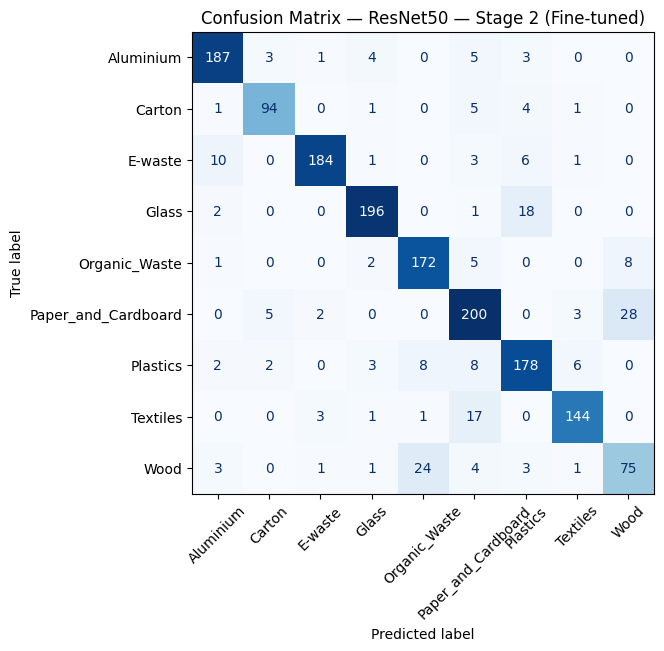

                     precision    recall  f1-score   support

          Aluminium       0.91      0.92      0.91       203
             Carton       0.90      0.89      0.90       106
            E-waste       0.96      0.90      0.93       205
              Glass       0.94      0.90      0.92       217
      Organic_Waste       0.84      0.91      0.88       188
Paper_and_Cardboard       0.81      0.84      0.82       238
           Plastics       0.84      0.86      0.85       207
           Textiles       0.92      0.87      0.89       166
               Wood       0.68      0.67      0.67       112

           accuracy                           0.87      1642
          macro avg       0.87      0.86      0.86      1642
       weighted avg       0.87      0.87      0.87      1642



In [ ]:
#  Stage 2 — fine-tune deeper layers
for layer in base_resnet.layers[-60:]:  # unfreeze last 60 layers
    layer.trainable = True

resnet_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
print("\n Stage 2: fine-tuning last 60 layers...")
hist_resnet_s2 = resnet_model.fit(
    train_resnet, validation_data=val_resnet,
    epochs=12, callbacks=common_callbacks('resnet50_stage2'), verbose=1
)
plot_history(hist_resnet_s2, "ResNet50 — Stage 2 (Fine-tuned)")
eval_and_report(resnet_model, val_resnet, "ResNet50 — Stage 2 (Fine-tuned)")

In [23]:
# STEP 9 — Save all models for team compare
save_root = '/content/drive/MyDrive/Waste_Images'

resnet_model.save(os.path.join(save_root, 'model_resnet50_fixed.keras'))
print(" Saved:ResNet50 to Drive.")

 Saved:ResNet50 to Drive.


In [ ]:
# STEP 10 — Quick comparison table (val acc)
def best_val_acc(h):  # grab best validation accuracy recorded
    return float(np.max(h.history['val_accuracy']))

summary = {

    "ResNet50 (Stage 1)": best_val_acc(hist_resnet_s1),
    "ResNet50 (Fine-tuned)": best_val_acc(hist_resnet_s2)
}
summary
